<a href="https://colab.research.google.com/github/Kshitij-Panday/Aiml_Lab/blob/main/A_B4_65_Kshitij_Panday_Lab_Linear_Regression_Normal_Equation(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AIML Lab: Linear Regression using **Normal Equation** (Matrix Method)

**Topic:** Linear Regression (Supervised Learning) — Parameter estimation using the **Normal Equation**  
**Dataset used in this lab (toy data):** (x, y) = (1, 5), (2, 7), (3, 9)

---
## Aim
To implement **Linear Regression** using the **Normal Equation (closed-form solution)** and interpret the learned parameters \(\theta_0\) and \(\theta_1\).

## Objectives
By the end of this lab, students will be able to:
1. Perform quick EDA (inspect values, plot scatter) for a simple dataset.
2. Form the design matrix \(X\) (including the intercept term).
3. Compute \(\theta\) using the Normal Equation:  
   \[ \theta = (X^T X)^{-1} X^T y \]
4. Verify the model by predicting outputs and comparing with actual values.
5. Explain why Normal Equation gives an **exact minimum** for MSE (when \(X^T X\) is invertible).

---
## CO Mapping (as per your course outcomes)
- **CO22:** Perform exploratory data analysis to prepare datasets for machine learning models.  
- **CO33:** Implement and analyze supervised learning algorithms on a given dataset.  
- **CO4:** Select suitable technique (Normal Equation) to solve regression efficiently.  
- **CO5:** Evaluate and interpret performance using errors / MSE and inference from coefficients.

---
## Prerequisites
- Python basics, NumPy, Matplotlib
- Understanding of vectors and matrices (transpose, inverse)


## Necessary Theory (Word Equation-ready)

### 1) What is Linear Regression?
We model a relationship between input \(x\) and output \(y\) as a straight line:

\[ h_\theta(x) = \theta_0 + \theta_1 x \]

- \(\theta_0\): intercept (bias)
- \(\theta_1\): slope (weight)

### 2) Cost Function (Mean Squared Error)
For \(m\) training examples:

\[ J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2 \]

### 3) Normal Equation (Closed-form Solution)
Instead of iterative Gradient Descent, we can directly compute \(\theta\):

\[ \theta = (X^T X)^{-1} X^T y \]

Where:
- \(X\) is the design matrix (first column is all 1’s for intercept)
- \(y\) is the target vector
- \(X^T\) is transpose of \(X\)

**Note:** If \(X^T X\) is not invertible, we use pseudo-inverse:
\[ \theta = X^{+} y \]
(NumPy provides `np.linalg.pinv`.)

### 4) Why Normal Equation?
- No learning rate \(\alpha\)
- No iterations required
- Gives exact minimum for MSE (when invertible)


## Procedure (Lab Steps)
1. Create/load the dataset.
2. Perform EDA: view table, plot scatter (x vs y).
3. Build the design matrix \(X\) by adding a column of ones.
4. Compute:
   - \(X^T X\)
   - \((X^T X)^{-1}\)
   - \(X^T y\)
5. Compute \(\theta = (X^T X)^{-1} X^T y\)
6. Form the final hypothesis \(h_\theta(x)\) and verify predictions.
7. (Optional) Compute MSE / cost to confirm best fit.

---
### Observation Table (fill in)
| x | y (Actual) | \(\hat{y}\) (Predicted) | Error \(\hat{y}-y\) |
|---:|---:|---:|---:|
| 1 | 5 |  |  |
| 2 | 7 |  |  |
| 3 | 9 |  |  |


In [ ]:
# Step 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make outputs easier to read
np.set_printoptions(precision=4, suppress=True)


In [ ]:
# Step 2: Create the toy dataset (x, y)

# Given: (1,4), (2,6), (3,7), (5,15)
data = pd.DataFrame({
    "x": [1, 2, 3, 5],
    "y": [4, 6,7,15]
})
print(data)
display(data)
print("m(number of examples)=",len(data))

   x   y
0  1   4
1  2   6
2  3   7
3  5  15


,x,y
0,1,4
1,2,6
2,3,7
3,5,15


m(number of examples)= 4


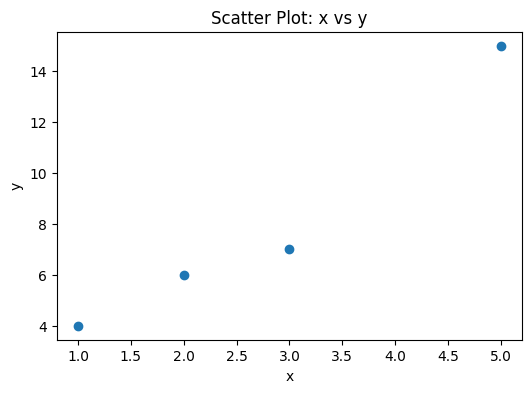

In [ ]:
# Step 3: Quick EDA (scatter plot)
plt.figure(figsize=(6,4))
plt.scatter(data["x"], data["y"])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter Plot: x vs y")
plt.show()

# Observation:
# Points look almost perfectly linear/scattered.


In [ ]:
u=np.ones(len(data))
print(u)
v=data["x"].values
print(v)

[1. 1. 1. 1.]
[1 2 3 5]


In [ ]:
# Step 4: Build design matrix X and target vector y
# Add intercept term (Ones column)
X = np.c_[np.ones(len(data)), data["x"].values]   # shape (m, 2)
y = data["y"].values.reshape(-1, 1)        # shape (m, 1)

print("X =")
print(X)
print("\ny =")
print(y)
print("\nShapes -> X:", X.shape, ", y:", y.shape)

X =
[[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 5.]]

y =
[[ 4]
 [ 6]
 [ 7]
 [15]]

Shapes -> X: (4, 2) , y: (4, 1)


In [ ]:
# Step 5: Compute theta using the Normal Equation
# theta = (X^T X)^(-1) X^T y

XT = X.T

XTX = XT @ X
XTy = XT @ y #

print("X^T X =")
print(XTX)
print("\nX^T y =")
print(XTy)

# Inverse (or use pseudo-inverse for safety)
XTX_inv = np.linalg.inv(XTX)
#theta = np.linalg.solve(XTX,XTy)
theta = XTX_inv @ XTy

print("\n(X^T X)^(-1) =")
print(XTX_inv)

print("\nLearned parameters (theta) =")
print(theta)

theta0, theta1 = float(theta[0,0]), float(theta[1,0])
print(f"\nθ0 = {theta0:.4f},  θ1 = {theta1:.4f}")

X^T X =
[[ 4. 11.]
 [11. 39.]]

X^T y =
[[ 32.]
 [112.]]

(X^T X)^(-1) =
[[ 1.1143 -0.3143]
 [-0.3143  0.1143]]

Learned parameters (theta) =
[[0.4571]
 [2.7429]]

θ0 = 0.4571,  θ1 = 2.7429


,x,y,y_pred,error
0,1,4,3.200000,-0.800000
1,2,6,5.942857,-0.057143
2,3,7,8.685714,1.685714
3,5,15,14.171429,-0.828571



Cost J(θ) = 0.521429
MSE       = 1.042857


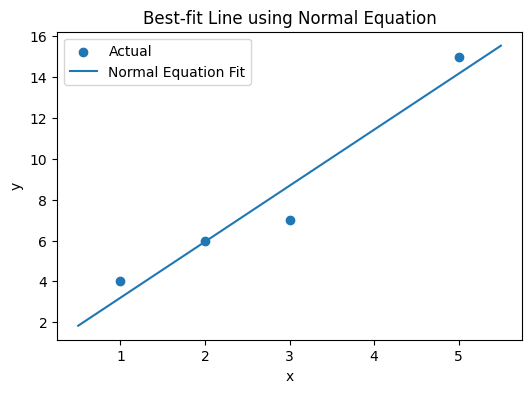

In [ ]:
# Step 6: Final model and verification
# Hypothesis function:
# h(x) = theta0 + theta1*x
def h(x):
    return theta0 + theta1 * x
# Compute predicted y-values for each x
data["y_pred"] = h(data["x"])
# Compute prediction error = predicted value - actual value
data["error"] = data["y_pred"] - data["y"]
# Display the updated table
display(data)
# Compute cost J(theta) and MSE
m = len(data)
J = (1/(2*m)) * np.sum((data["y_pred"].values - data["y"].values)**2)
MSE = np.mean((data["y_pred"].values - data["y"].values)**2)
print(f"\nCost J(θ) = {J:.6f}")
print(f"MSE       = {MSE:.6f}")

# Plot regression line
plt.figure(figsize=(6,4))
plt.scatter(data["x"], data["y"], label="Actual")
x_line = np.linspace(min(data["x"]) - 0.5, max(data["x"]) + 0.5, 50)
plt.plot(x_line, h(x_line), label="Normal Equation Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Best-fit Line using Normal Equation")
plt.legend()
plt.show()

## Detailed Explanation (What each step is doing)

### Why do we add a Ones column?
To include the intercept \(\theta_0\) in matrix form.

For one example with input \(x\), we represent it as:
\[ [1,\ x] \]
so that:
\[ [1,\ x] \begin{bmatrix}\theta_0\\\theta_1\end{bmatrix} = \theta_0 + \theta_1 x \]

### What do these matrix terms mean?
- \(X^T X\) combines information about the inputs (like sums of x and x²).
- \(X^T y\) combines input-output coupling (like sums of xy).
- \((X^T X)^{-1}\) “undoes” the scaling/rotation from \(X^T X\).

### Interpretation of \(\theta_0, \theta_1\)
- \(\theta_1\) tells how much \(y\) changes when \(x\) increases by 1.
- \(\theta_0\) is the predicted \(y\) when \(x=0\).

For this toy data, you should get:
\[ h(x) = 3 + 2x \]
which matches all points exactly.


## Viva / Review Questions
1. Define supervised learning and regression with one example.
2. Write the hypothesis for univariate linear regression.
3. Why do we add a column of ones to \(X\)?
4. Write the Normal Equation.
5. When can \((X^T X)^{-1}\) fail to exist?
6. What is the role of pseudo-inverse \(X^+\)?
7. Compare Normal Equation and Gradient Descent (2 points).
8. Interpret \(\theta_0\) and \(\theta_1\) for this dataset.
9. If we add more noisy points, will the line pass through all points? Why?
10. What does MSE measure?


## Extensions (Optional Tasks)
1. Add 2 more points like (4, 11) and (5, 13). Recompute \(\theta\). What changes?
2. Add noise to y, e.g., (3, 8.5). Does MSE become non-zero?
3. Try `np.linalg.pinv(X) @ y` and compare with the inverse-based solution.
4. Implement Gradient Descent and compare convergence with Normal Equation.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# Example: your data must have columns x and y
x_data = data["x"].values
y_data = data["y"].values

# Hypothesis
def h(theta0, theta1, x):
    return theta0 + theta1 * x

# Cost function
def compute_cost(theta0, theta1, x, y):
    m = len(x)
    y_pred = theta0 + theta1 * x
    return (1/(2*m)) * np.sum((y_pred - y)**2)

# Interactive function
def visualize(theta0, theta1):
    y_pred = h(theta0, theta1, x_data)
    J = compute_cost(theta0, theta1, x_data, y_data)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Plot 1: Data + regression line
    ax[0].scatter(x_data, y_data, label="Actual")
    x_line = np.linspace(min(x_data)-0.5, max(x_data)+0.5, 100)
    ax[0].plot(x_line, h(theta0, theta1, x_line), label="Tuned Line")
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("y")
    ax[0].set_title(f"Regression Line\nJ(theta) = {J:.4f}")
    ax[0].legend()

    # Plot 2: Actual vs predicted
    ax[1].scatter(range(len(y_data)), y_data, label="Actual")
    ax[1].scatter(range(len(y_pred)), y_pred, label="Predicted")
    ax[1].set_xlabel("Sample index")
    ax[1].set_ylabel("y")
    ax[1].set_title("Actual vs Predicted")
    ax[1].legend()

    plt.show()

    print(f"theta0 = {theta0:.3f}, theta1 = {theta1:.3f}, Cost J = {J:.6f}")

interact(
    visualize,
    theta0=FloatSlider(min=-10, max=10, step=0.1, value=0),
    theta1=FloatSlider(min=-10, max=10, step=0.1, value=1)
);

interactive(children=(FloatSlider(value=0.0, description='theta0', max=10.0, min=-10.0), FloatSlider(value=1.0…

In [ ]:
import numpy as np

# Assume a 2x2 matrix B
B = np.array([[1, 2],
              [3, 4]])

print("Matrix B =")
print(B)
print("\nUsing .T")
print("B.T =")
print(B.T)
print("\nUsing .shape")
print("B.shape =", B.shape)

# -----------------------------
# 2. * operator
# -----------------------------
# * means element-wise multiplication

print("\nElement-wise multiplication: B * B")
print(B * B)

# -----------------------------
# 3. @ operator
# -----------------------------
# @ means matrix multiplication

print("\nMatrix multiplication: B @ B")
print(B @ B)

Matrix B =
[[1 2]
 [3 4]]

Using .T
B.T =
[[1 3]
 [2 4]]

Using .shape
B.shape = (2, 2)

Element-wise multiplication: B * B
[[ 1  4]
 [ 9 16]]

Matrix multiplication: B @ B
[[ 7 10]
 [15 22]]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Checkbox
from mpl_toolkits.mplot3d import Axes3D

# -------------------------------------------------
# Example dataset
# -------------------------------------------------
data = pd.DataFrame({
    "x": [1, 2, 3, 5],
    "y": [4, 6, 7, 15]
})

x_data = data["x"].values
y_data = data["y"].values
m = len(x_data)

# -------------------------------------------------
# Hypothesis function
# -------------------------------------------------
def h(theta0, theta1, x):
    return theta0 + theta1 * x

# -------------------------------------------------
# Cost function
# -------------------------------------------------
def compute_cost(theta0, theta1, x, y):
    m = len(x)
    y_pred = theta0 + theta1 * x
    return (1 / (2 * m)) * np.sum((y_pred - y) ** 2)

# -------------------------------------------------
# Gradients
# -------------------------------------------------
def compute_gradients(theta0, theta1, x, y):
    m = len(x)
    y_pred = theta0 + theta1 * x
    error = y_pred - y

    dtheta0 = (1 / m) * np.sum(error)
    dtheta1 = (1 / m) * np.sum(error * x)

    return dtheta0, dtheta1

# -------------------------------------------------
# Gradient Descent path
# -------------------------------------------------
def gradient_descent_path(x, y, theta0_init, theta1_init, alpha, num_iters):
    theta0 = theta0_init
    theta1 = theta1_init

    theta0_history = [theta0]
    theta1_history = [theta1]
    J_history = [compute_cost(theta0, theta1, x, y)]

    for _ in range(num_iters):
        dtheta0, dtheta1 = compute_gradients(theta0, theta1, x, y)

        theta0 = theta0 - alpha * dtheta0
        theta1 = theta1 - alpha * dtheta1

        theta0_history.append(theta0)
        theta1_history.append(theta1)
        J_history.append(compute_cost(theta0, theta1, x, y))

    return theta0_history, theta1_history, J_history

# -------------------------------------------------
# Precompute contour/surface grid
# -------------------------------------------------
theta0_vals = np.linspace(-5, 10, 120)
theta1_vals = np.linspace(-1, 5, 120)

T0, T1 = np.meshgrid(theta0_vals, theta1_vals)
J_vals = np.zeros(T0.shape)

for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        J_vals[i, j] = compute_cost(T0[i, j], T1[i, j], x_data, y_data)

# -------------------------------------------------
# Interactive visualization
# -------------------------------------------------
def visualize(theta0=0.0, theta1=1.0, show_gd_path=True, alpha=0.08, num_iters=20):
    J_current = compute_cost(theta0, theta1, x_data, y_data)

    # Gradient descent path starting from current slider values
    theta0_hist, theta1_hist, J_hist = gradient_descent_path(
        x_data, y_data, theta0, theta1, alpha, num_iters
    )

    fig = plt.figure(figsize=(18, 10))

    # ---------------------------------------------
    # 1. Regression line
    # ---------------------------------------------
    ax1 = fig.add_subplot(2, 2, 1)
    ax1.scatter(x_data, y_data, label="Actual Data")
    x_line = np.linspace(min(x_data) - 0.5, max(x_data) + 0.5, 100)
    ax1.plot(x_line, h(theta0, theta1, x_line), label="Tuned Line")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_title(f"Regression Line\nCurrent Cost J = {J_current:.4f}")
    ax1.legend()
    ax1.grid(True)

    # ---------------------------------------------
    # 2. Contour plot
    # ---------------------------------------------
    ax2 = fig.add_subplot(2, 2, 2)
    contour = ax2.contour(T0, T1, J_vals, levels=30)
    ax2.clabel(contour, inline=True, fontsize=8)

    # Current theta point
    ax2.plot(theta0, theta1, 'ro', markersize=8, label="Current theta")

    # Optional GD path
    if show_gd_path:
        ax2.plot(theta0_hist, theta1_hist, 'bo-', linewidth=2, markersize=4, label="GD Path")
        ax2.plot(theta0_hist[0], theta1_hist[0], 'ks', markersize=8, label="Start")
        ax2.plot(theta0_hist[-1], theta1_hist[-1], 'g*', markersize=12, label="GD End")

    ax2.set_xlabel(r'$\theta_0$')
    ax2.set_ylabel(r'$\theta_1$')
    ax2.set_title(r'2D Contour Plot of $J(\theta_0,\theta_1)$')
    ax2.legend()
    ax2.grid(True)

    # ---------------------------------------------
    # 3. 3D Surface plot
    # ---------------------------------------------
    ax3 = fig.add_subplot(2, 2, 3, projection='3d')
    ax3.plot_surface(T0, T1, J_vals, alpha=0.65)

    # Current theta point
    ax3.scatter(theta0, theta1, J_current, color='red', s=60, label='Current theta')

    # Optional GD path
    if show_gd_path:
        ax3.plot(theta0_hist, theta1_hist, J_hist, 'bo-', linewidth=2, markersize=4)
        ax3.scatter(theta0_hist[0], theta1_hist[0], J_hist[0], color='black', s=50)
        ax3.scatter(theta0_hist[-1], theta1_hist[-1], J_hist[-1], color='green', s=80)

    ax3.set_xlabel(r'$\theta_0$')
    ax3.set_ylabel(r'$\theta_1$')
    ax3.set_zlabel(r'$J(\theta)$')
    ax3.set_title(r'3D Surface Plot of $J(\theta_0,\theta_1)$')

    # ---------------------------------------------
    # 4. Cost vs iteration
    # ---------------------------------------------
    ax4 = fig.add_subplot(2, 2, 4)
    if show_gd_path:
        ax4.plot(range(len(J_hist)), J_hist, 'mo-', linewidth=2, markersize=4)
        ax4.set_title("Cost vs Iteration (from current slider theta)")
    else:
        ax4.bar(["Current Cost"], [J_current])
        ax4.set_title("Current Cost Only")

    ax4.set_xlabel("Iteration")
    ax4.set_ylabel(r'$J(\theta)$')
    ax4.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Current theta0 = {theta0:.3f}")
    print(f"Current theta1 = {theta1:.3f}")
    print(f"Current cost   = {J_current:.6f}")

    if show_gd_path:
        print(f"GD final theta0 = {theta0_hist[-1]:.6f}")
        print(f"GD final theta1 = {theta1_hist[-1]:.6f}")
        print(f"GD final cost   = {J_hist[-1]:.6f}")

# -------------------------------------------------
# Sliders
# -------------------------------------------------
interact(
    visualize,
    theta0=FloatSlider(min=-5, max=10, step=0.1, value=0.0, description='theta0'),
    theta1=FloatSlider(min=-1, max=5, step=0.1, value=1.0, description='theta1'),
    show_gd_path=Checkbox(value=True, description='Show GD Path'),
    alpha=FloatSlider(min=0.01, max=0.5, step=0.01, value=0.08, description='alpha'),
    num_iters=IntSlider(min=1, max=50, step=1, value=20, description='iters')
);

interactive(children=(FloatSlider(value=0.0, description='theta0', max=10.0, min=-5.0), FloatSlider(value=1.0,…